In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("placement.csv")

In [5]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [7]:
df.shape

(1000, 3)

In [9]:
df.isnull().sum()

cgpa                    0
placement_exam_marks    0
placed                  0
dtype: int64

In [11]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


<Axes: xlabel='placement_exam_marks', ylabel='Density'>

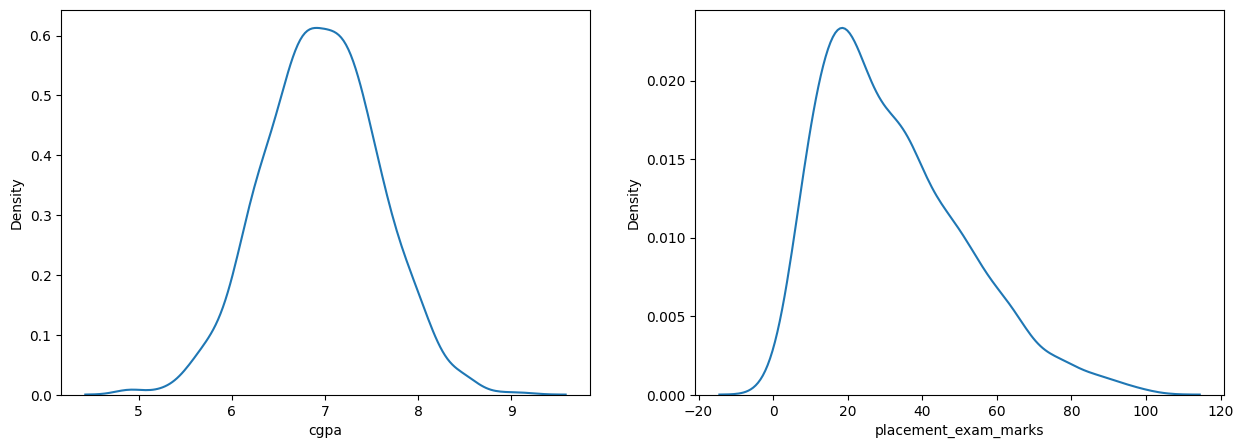

In [19]:
fig,ax=plt.subplots(1,2,figsize=(15,5))

sns.kdeplot(data=df,x="cgpa",ax=ax[0])

sns.kdeplot(data=df,x="placement_exam_marks",ax=ax[1])

In [20]:
#the iqr detection technique is use on skewed data-->placement_exam_marks column is skewed.

In [26]:
df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [43]:
percentile25=df["placement_exam_marks"].quantile(0.25)

In [44]:
percentile25

np.float64(17.0)

In [45]:
percentile75=df["placement_exam_marks"].quantile(0.75)

In [46]:
percentile75

np.float64(44.0)

In [47]:
iqr=percentile75 - percentile25

In [48]:
iqr

np.float64(27.0)

In [36]:
#my method you know the df["placement_exam_marks"].describe()-->see 25 &75% used that number 

In [ ]:
# df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

In [ ]:
# iqr=44.0-17.0

In [ ]:
# iqr

27.0

In [56]:
upper_limit=percentile75+1.5*iqr

In [59]:
upper_limit

np.float64(84.5)

In [61]:
lower_limit=percentile25-1.5*iqr

In [62]:
lower_limit

np.float64(-23.5)

In [ ]:
#finding outlier

In [63]:
df[df["placement_exam_marks"] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [65]:
df[df["placement_exam_marks"] < lower_limit]

,cgpa,placement_exam_marks,placed


In [67]:
#Trimming

In [69]:
new_df_trimming=df[(df["placement_exam_marks"]<upper_limit) & (df["placement_exam_marks"]>lower_limit)]

In [71]:
new_df_trimming.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [73]:
new_df_trimming.shape

(985, 3)

In [75]:
new_df_trimming["placement_exam_marks"].describe()

count    985.000000
mean      31.339086
std       17.857633
min        0.000000
25%       17.000000
50%       28.000000
75%       43.000000
max       83.000000
Name: placement_exam_marks, dtype: float64

In [77]:
df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

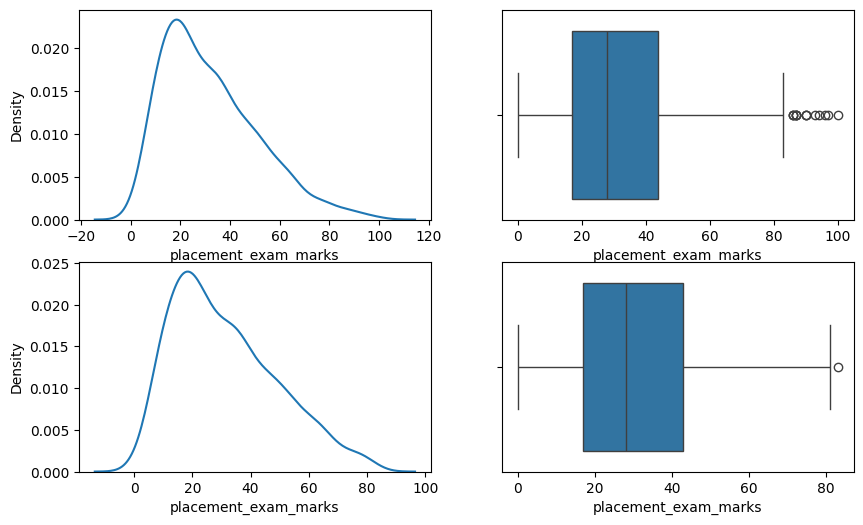

In [86]:
fig,ax=plt.subplots(2,2,figsize=(10,6))

sns.kdeplot(data=df,x="placement_exam_marks",ax=ax[0][0])
sns.boxplot(data=df,x="placement_exam_marks",ax=ax[0][1])

sns.kdeplot(data=new_df_trimming,x="placement_exam_marks",ax=ax[1][0])
sns.boxplot(data=new_df_trimming,x="placement_exam_marks",ax=ax[1][1])

In [79]:
#CAPPING

In [81]:
capping=df.copy()

In [83]:
capping.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [88]:
capping["placement_exam_marks"]=capping["placement_exam_marks"].clip(lower=lower_limit,upper=upper_limit)

In [91]:
capping["placement_exam_marks"].describe()

count    1000.000000
mean       32.136500
std        18.865419
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max        84.500000
Name: placement_exam_marks, dtype: float64

In [93]:
capping.shape

(1000, 3)

<Axes: xlabel='placement_exam_marks'>

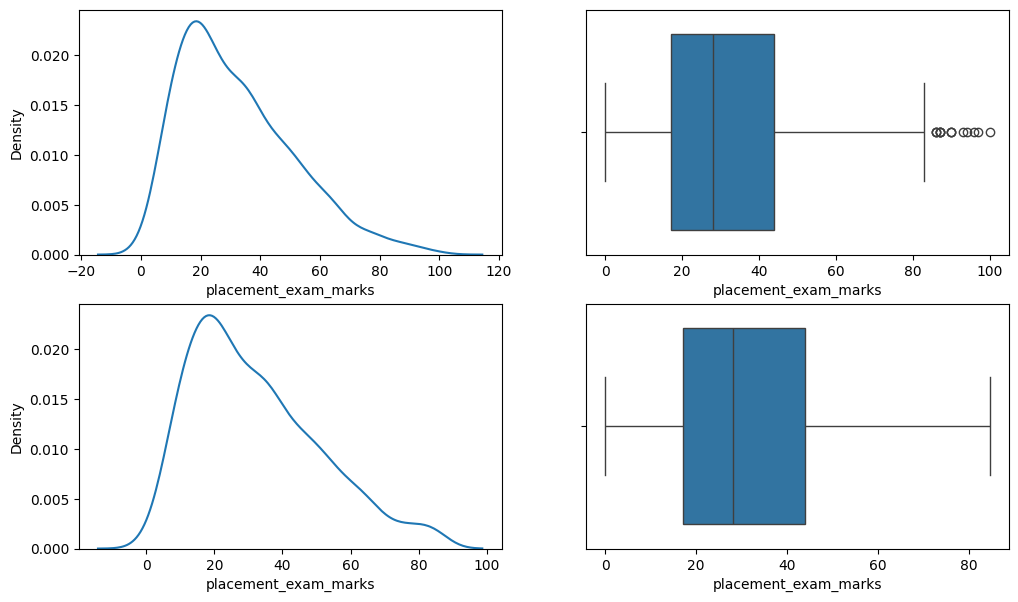

In [94]:
fig,ax=plt.subplots(2,2,figsize=(12,7))

sns.kdeplot(data=df,x="placement_exam_marks",ax=ax[0][0])
sns.boxplot(data=df,x="placement_exam_marks",ax=ax[0][1])

sns.kdeplot(data=capping,x="placement_exam_marks",ax=ax[1][0])
sns.boxplot(data=capping,x="placement_exam_marks",ax=ax[1][1])